In [1]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt
import os

from scipy import stats

import sys
sys.path.append("../")
from spore.conventions import units

In [2]:
import h5py as h5

start is from above end is through the earth

In [7]:
# with h5.File("../resources/new_example_detector_response.h5", "w") as h5fnew:
#     with h5.File("../resources/example_detector_response.h5") as h5fold:
#         for k, v in h5fold.items():
#             gp = h5fnew.create_group(k)
#             if "effective_area" in k:
                
# #                 zeniths = np.pi/2 + v["declinations"][:]
#                 zeniths = np.pi/2 + v["zeniths"][:]
#                 zeniths = np.hstack([0, zeniths, np.pi])
#                 effas = v["tabulated_values"]
#                 effas = np.transpose(np.vstack([effas[:, 0], np.transpose(effas), effas[:, -1]]))
                
#                 gp.create_dataset("energies", data=v["energiess"][:])
#                 gp.create_dataset("zeniths", data=zeniths)
#                 gp.create_dataset("tabulated_values", data=effas)
#                 gp.create_dataset("upper_bounds", data=v["upper_bounds"])
#                 gp.create_dataset("lower_bounds", data=lbs)
#                 print(v["lower_bounds"][:])
#                 print(zeniths.shape, effas.shape)
                
#             else:
#                 for k1, v1 in v.items():
#                     if k1=="es":
#                         gp.create_dataset("energies", data=v["es"][:])
#                     else:
#                         gp.create_dataset(k1, data=v[k1][:])
                    

In [106]:
# lbs = [[0, lower_bounds[0][0]], lower_bounds[1]]
# lbs

[[0, 13.397940008672037], [15.9862667245, 8.602059991325]]

In [10]:
h5f = h5.File("../resources/example_detector_response.h5")

In [13]:
cm = 8065.54815355

/var/folders/rr/4sp_7qnn509b31qkr6c2_6sr0000gp/T/ipykernel_18710/3486627475.py:5: RuntimeWarning: divide by zero encountered in log10
  np.log10(vs / cm**2)[::-1],


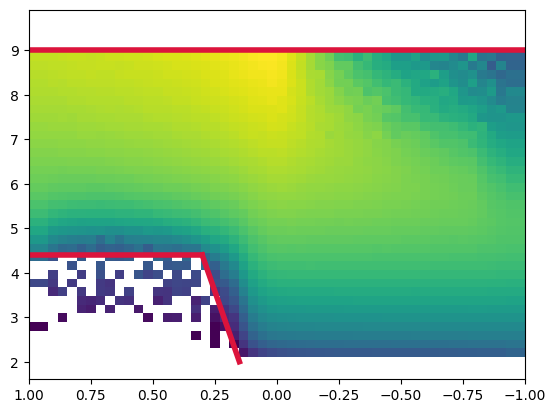

In [14]:
vs = h5f["track_effective_area/tabulated_values"][:, :]
ys = h5f["track_effective_area/energies"][:]
xs = h5f["track_effective_area/zeniths"][:]
plt.imshow(
    np.log10(vs / cm**2)[::-1],
    aspect="auto",
    extent=[1, -1, np.log10(ys).min()-9, np.log10(ys).max()-9]
)

lower_bounds = [
    [np.log10(2.5e4 * 1e9)],
    [15.9862667245, np.log10(np.power(10, -0.397940008675) * 1e9)],
]
upper_bounds = [
    [np.log10(1e9 * 1e9)]
]

plt.plot(
    [1, 0.3],
    np.poly1d(lower_bounds[0])([1, 0.3]) - 9,
    lw=4,
    c="crimson"
)
plt.plot(
    [0.3, 0.15],
    np.poly1d(lower_bounds[1])([0.3, 0.15]) - 9,
    lw=4,
    c="crimson"
)
plt.plot(
    [-1, 1],
    np.poly1d(upper_bounds[0])([-1, 1]) - 9,
    lw=4,
    c="crimson"
)

plt.show()

In [16]:
with h5.File("../resources/example_detector_response.h5") as h5f:
    print(h5f["track_effective_area"].keys())
    zeniths = np.pi/2 + h5f["track_effective_area/zeniths"][:]
    print(np.hstack([0, zeniths, np.pi]))
#     print(h5f["track_effective_area/es"].shape)
    effas = h5f["track_effective_area/tabulated_values"]
    effas = np.transpose(np.vstack([effas[:, 0], np.transpose(effas), effas[:, -1]]))
    print(effas.shape)
    

<KeysViewHDF5 ['energies', 'lower_bounds', 'tabulated_values', 'upper_bounds', 'zeniths']>
[0.         1.57079633 1.71269159 1.91401532 2.01960774 2.10504161
 2.17930537 2.24632601 2.30811067 2.36588107 2.42050987 2.47260795
 2.52261163 2.57095725 2.61781935 2.66345971 2.70805287 2.7516861
 2.7946212  2.83685817 2.87848427 2.91967404 2.96051474 3.00109365
 3.04141075 3.08155333 3.12160863 3.16157667 3.20163198 3.24177455
 3.28209166 3.32267056 3.36351127 3.40470104 3.44632714 3.48856411
 3.53149921 3.57513244 3.6197256  3.66536596 3.71222805 3.76057367
 3.81057736 3.86267543 3.91730424 3.97507464 4.03685929 4.10387994
 4.1781437  4.26357756 4.36916998 4.57049371 4.71238898 3.14159265]
(40, 54)


In [18]:
globs = {
    "es": np.logspace(2, 6, 50) * units.GeV,
    "angles": np.linspace(0, np.pi, 10000),
    "us": np.linspace(0, 0.9999, 1000), # The slight difference from 0 helps with numerics
    "track_params": (90 * units.GeV, 1.5, 0.5, 1.5), # These parameters were found empirically and are only meant as heuristics
    "cascade_params": (90 * units.GeV, 6, 0.4, 6),
    "fname": "../resources/example_detector_response.h5",
}

In [19]:
# Make the file if it doesn't exist already
if not os.path.exists(globs["fname"]):
    with h5.File(fname, "w") as _:
        pass

In [20]:
def shape_parameter(e, e0, a, exp, p0):
    return a  / (np.log10(e) - np.log10(e0))**exp + p0

# Make CDFs
You could get these however you want, but I am just making up something that looks reasonable for now. In practice, you would want to get these from a paper or something

## First we do it for tracks

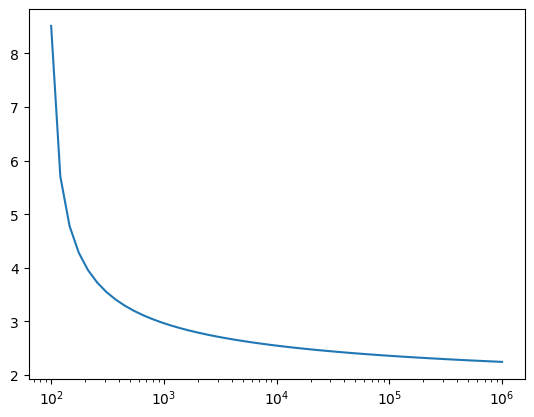

In [21]:
plt.plot(globs["es"] / units.GeV, shape_parameter(globs["es"], *globs["track_params"]))
plt.semilogx()
plt.show()

In [22]:
median_res = 0.25
f = lambda shape_p: stats.gamma.cdf(median_res, shape_p) - 0.5
from scipy.optimize import ridder
shape_p0 = ridder(f, 0.1, 20)
delta_psi_cdf = lambda delta_psi: stats.gamma.cdf(delta_psi, shape_p0)
delta_psi_pdf = lambda delta_psi: stats.gamma.pdf(delta_psi, shape_p0)

In [23]:
track_cdfs = np.zeros((len(globs["es"]), len(globs["angles"])))
track_cdfs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

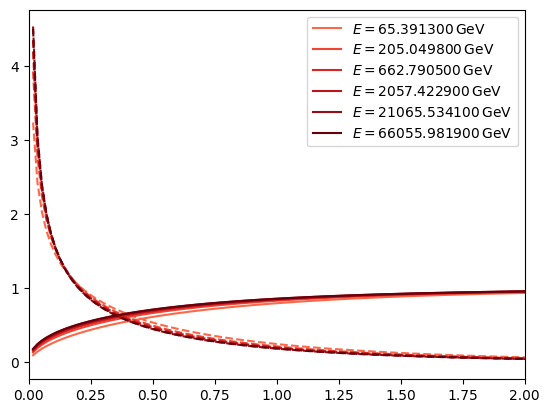

In [25]:
from scipy.optimize import ridder

# Load data
data = np.genfromtxt("../resources/MedianResThrougGoingAll.csv", delimiter=";")
track_es = data[:, 0] * units.GeV
track_median_deltapsis = data[:, 1]

# Preallocate memory
track_cdfs = np.zeros((len(track_es), len(globs["angles"])))

# Beautifying 
from matplotlib import cm
cmap = cm.Reds
colors = cmap(np.linspace(.5, 1, len(track_es)))

for idx, (e, median_psi, color) in enumerate(zip(track_es, track_median_deltapsis, colors)):
    # Real things
    f = lambda shape_p: stats.gamma.cdf(median_psi, shape_p) - 0.5
    shape_p0 = ridder(f, 0.1, 20)
    delta_psi_cdf = lambda delta_psi: stats.gamma.cdf(delta_psi, shape_p0)
    delta_psi_pdf = lambda delta_psi: stats.gamma.pdf(delta_psi, shape_p0)
    # Put output into preallocated array
    track_cdfs[idx, :] = delta_psi_cdf(np.degrees(globs["angles"]))
    
    # Beautifying 
    label1 = r"$E=%f\,\mathrm{GeV}$" % (e / units.GeV)
    label2 = ""
    plt.plot(
        np.degrees(globs["angles"])[1:],
        delta_psi_cdf(np.degrees(globs["angles"])[1:]),
        label=label1,
        color=color
    )
    plt.plot(
        np.degrees(globs["angles"])[1:],
        delta_psi_pdf(np.degrees(globs["angles"])[1:]),
        label=label2,
        ls="--",
        color=color
    )
plt.legend()
plt.xlim(0, 2)
plt.show()

In [26]:

# for k, 

# plt.plot(np.degrees(globs["xs"])[1:], delta_psi_cdf(np.degrees(globs["xs"])[1:]), label="CDF")
# plt.plot(np.degrees(globs["xs"])[1:], delta_psi_pdf(np.degrees(globs["xs"])[1:]), label="PDF", ls="--")
# plt.legend()
# plt.xlim(0, 2)
# plt.show()

In [27]:
# median_ress = <load your data>
for median_res in median_ress:
    f = lambda shape_p: stats.gamma.cdf(median_res, shape_p) - 0.5
    shape_p0 = ridder(f, 0.1, 20)
    delta_psi_cdf = lambda delta_psi: stats.gamma.cdf(delta_psi, shape_p0)

NameError: name 'median_ress' is not defined

In [28]:


for idx, e in enumerate(globs["es"]):
    # This is the value that you will replace
    shape_p0 = shape_parameter(e, *globs["track_params"])
    cdf = stats.gamma.cdf(np.degrees(globs["us"]), shape_p0)
    track_cdfs[idx, :] = cdf

ValueError: could not broadcast input array from shape (1000,) into shape (10000,)

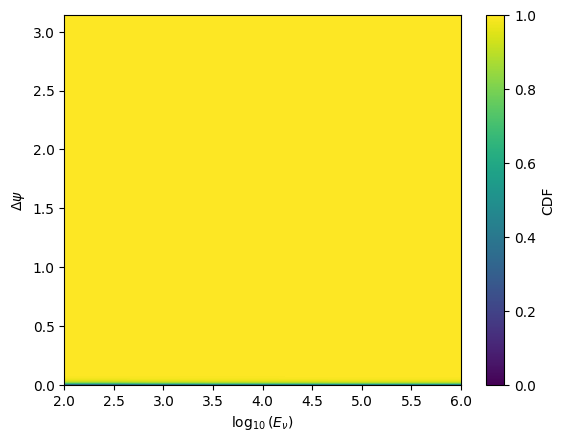

In [16]:
# Quick little sanity check
fig, ax = plt.subplots()

im = ax.imshow(
    track_cdfs.T[::-1],
    aspect="auto", 
    extent=[
        np.log10(globs["es"][0] / units.GeV),
        np.log10(globs["es"][-1] / units.GeV),
        globs["angles"][0],
        globs["angles"][-1]
    ]
)

ax.set_xlabel(r"$\log_{10}(E_{\nu})$")
ax.set_ylabel(r"$\Delta\psi$")

plt.colorbar(im, label="CDF")
plt.show()

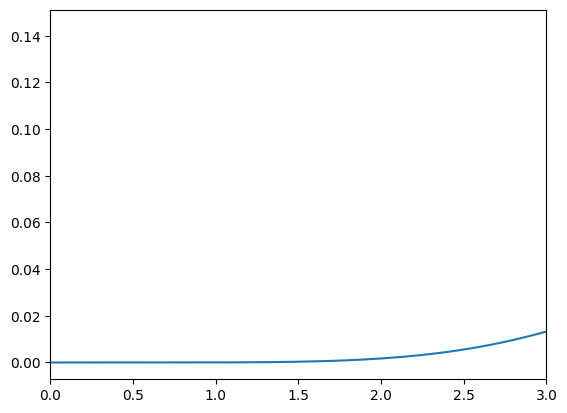

In [27]:
plt.plot(np.degrees(globs["us"]), stats.gamma.pdf(np.degrees(globs["us"]), shape_p0))
plt.xlim(0, 3)
plt.show()

## Now let's do it again for cascades

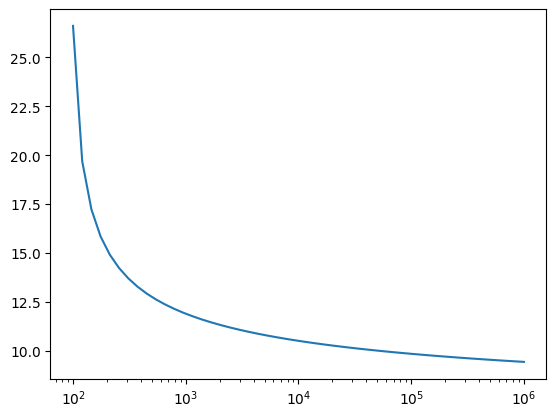

In [20]:
plt.plot(globs["es"] / units.GeV, shape_parameter(globs["es"], *globs["cascade_params"]))
plt.semilogx()
plt.show()

In [22]:
# Put the CDF into a table
cascade_cdfs = np.zeros((len(globs["es"]), len(globs["es"])))
for idx, e in enumerate(globs["es"]):
    cdf = stats.gamma.cdf(np.degrees(globs["es"]), shape_parameter(e, *globs["cascade_params"]))
    cascade_cdfs[idx, :] = cdf

In [23]:
# Plot it just to make sure
im = plt.imshow(
    cascade_cdfs.T[::-1],
    aspect="auto",
    extent=[
        np.log10(globs["es"][0] / units.GeV),
        np.log10(globs["es"][-1] / units.GeV),
        globs["xs"][0],
        globs["xs"][-1]
    ]
)
plt.colorbar(im)
plt.show()

KeyError: 'xs'

# Okay, now the real fun begins

In [23]:
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import ridder

In [66]:
from tqdm import tqdm

In [67]:
import time
for idx in tqdm(range(100)):
    time.sleep(0.3)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:30<00:00,  3.29it/s]


In [64]:
# invert all the CDFS
track_cdfs_interp = RegularGridInterpolator(
    # Swap for tabulated_energies
    (np.log(globs["es"]),
    globs["xs"]),
    track_cdfs
)
cascade_cdfs_interp = RegularGridInterpolator(
    # Swap for tabulated_energies
    (np.log(globs["es"]),
     globs["xs"]),
    cascade_cdfs
)

inv_track_cdfs = np.zeros(
    # Swap for tabulated_energies
    (len(globs["es"]),
     len(globs["us"]))
)
inv_cascade_cdfs = np.zeros(
    # Swap for tabulated_energies
    (len(globs["es"]),
     len(globs["us"]))
)

# Do this separately for tracks and cascades
for idx, e in enumerate(tqdm(globs["es"])):
    f = lambda x: track_cdfs_interp((np.log(e), x))
    g = lambda x: cascade_cdfs_interp((np.log(e), x))
    for jdx, u in enumerate(globs["us"]):
        f_ = lambda x: f(x) - u
        g_ = lambda x: g(x) - u
        
        inv_track_cdfs[idx, jdx] = ridder(f_, 0, np.pi)
        inv_cascade_cdfs[idx, jdx] = ridder(g_, 0, np.pi)
        

NameError: name 'RegularGridInterpolator' is not defined

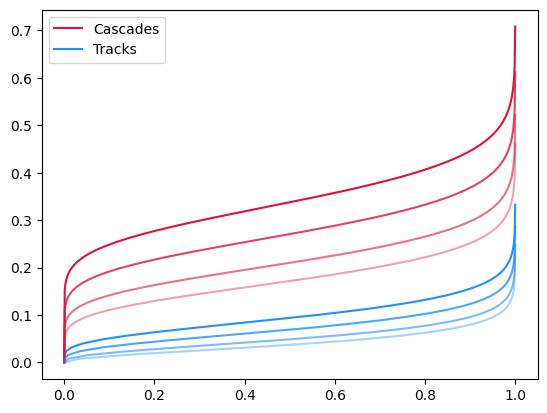

In [39]:
# plot some of them just to see what up
for alpha, idx in zip([1, 0.8, 0.6, 0.4], [1, 3, 10, 30]):
    label = ""
    if idx==1:
        label= "Cascades"
    plt.plot(globs["us"], inv_cascade_cdfs[idx, :], color="crimson", alpha=alpha, label=label)
    label = ""
    if idx==1:
        label= "Tracks"
    plt.plot(globs["us"], inv_track_cdfs[idx, :], color="dodgerblue", alpha=alpha, label=label)
plt.legend()
plt.show()

## Write the output file.
You'll have to change the file name.

In [ ]:
with h5.File(globs["fname"], "r+") as h5f:
    if "cascade_angular_response" in h5f.keys():
        del h5f["cascade_angular_response"]
    h5f.create_group("cascade_angular_response")
    h5f["cascade_angular_response"].create_dataset("us", data=globs["us"])
    h5f["cascade_angular_response"].create_dataset("es", data=globs["es"])
    h5f["cascade_angular_response"].create_dataset("inv_cdfs", data=inv_cascade_cdfs)
    
    if "track_angular_response" in h5f.keys():
        del h5f["track_angular_response"]
    h5f.create_group("track_angular_response")
    h5f["track_angular_response"].create_dataset("us", data=globs["us"])
    h5f["track_angular_response"].create_dataset("es", data=globs["es"])
    h5f["track_angular_response"].create_dataset("inv_cdfs", data=inv_track_cdfs)
    

# Let's look at how to sample this

In [15]:
# Delete these just to really play pretend
try:
    del inv_track_cdfs
except NameError:
    pass
try:
    del track_cdfs
except NameError:
    pass
try:
    del track_cdfs_interp
except NameError:
    pass
try:
    del inv_cascade_cdfs
except NameError:
    pass
try:
    del cascade_cdfs
except NameError:
    pass
try:
    del cascade_cdfs_interp
except NameError:
    pass

In [16]:
# First we interpolate
with h5.File(globs["fname"]) as h5f:
    cascade_i = RegularGridInterpolator(
        (np.log(h5f["cascade_angular_response/es"][:]), h5f["cascade_angular_response/us"][:]),
        h5f["cascade_angular_response/inv_cdfs"][:]
    )
    track_i = RegularGridInterpolator(
        (np.log(h5f["track_angular_response/es"][:]), h5f["track_angular_response/us"][:]),
        h5f["track_angular_response/inv_cdfs"][:]
    )

In [17]:
def sample_2d(e, interp, n=1):
    u = np.random.rand(n)
    # Replace values with those above the maximum u value.
    if hasattr(u, "__iter__"):
        u = np.where(u > interp.grid[1].max(), interp.grid[1].max(), u)
        u = np.where(u < interp.grid[1].min(), interp.grid[1].min(), u)
    return interp((np.log(e), u))

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 475.65it/s]


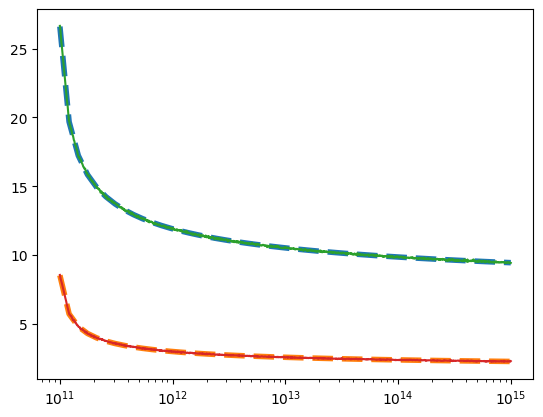

In [18]:
# Plot it on a fine grid to make sure that the interpolating hasn't done anything bananas
es_fine = np.logspace(2, 6, 1000) * units.GeV
track_means = []
cascade_means = []
for e in tqdm(es_fine):
    track_means.append(np.mean(sample_2d(e, track_i, 10_000)))
    cascade_means.append(np.mean(sample_2d(e, cascade_i, 10_000)))
    
plt.plot(globs["es"], shape_parameter(globs["es"], *globs["cascade_params"]), lw=4, ls="--")
plt.plot(globs["es"], shape_parameter(globs["es"], *globs["track_params"]), lw=4, ls="--")
plt.plot(es_fine, np.degrees(cascade_means))
plt.plot(es_fine, np.degrees(track_means))
plt.semilogx()
plt.show()

In [19]:
# # This is slow, but easily implemented. You can look at it for your own edification if you would like
# def sample_misreco_angle(e:float, interp: RegularGridInterpolator, n: int=1) -> float:
#     if n==1:
#         u = np.random.rand()
#         f = lambda x: interp((np.log(e), x)) - u
#         return ridder(f, 0, np.pi)
#     else:
#         us = np.random.rand(n)
#         out = np.zeros(us.shape)
#         for idx, u in enumerate(us):
#             f = lambda x: interp((np.log(e), x)) - u
#             out[idx] = ridder(f, 0, np.pi)
#         return out

# Now let's do this for energy.
This will be much simpler

## Make some fake data

In [20]:
sigma_cascade = (np.log(1.15) - np.log(0.85)) / 2
sigma_track = (np.log(3) - np.log(0.3)) / 2

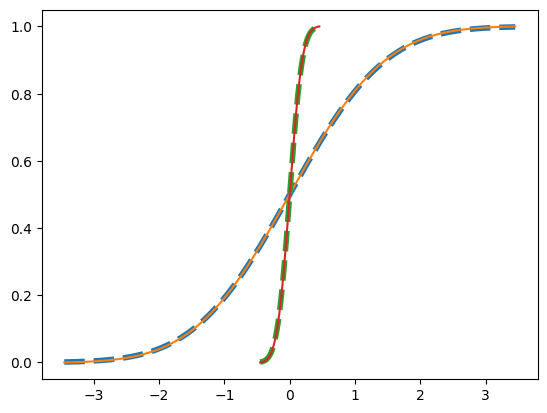

In [21]:
xs_track = np.linspace(-3 * sigma_track, 3*sigma_track, 2000)
xs_cascade = np.linspace(-3 * sigma_cascade, 3*sigma_cascade, 2000)
pdf_track = stats.norm.pdf(xs_track, loc=0, scale=sigma_track)
pdf_cascade = stats.norm.pdf(xs_cascade, loc=0, scale=sigma_cascade)

# Make these into CDFs
cdf_track = np.cumsum(pdf_track) / np.sum(pdf_track)
cdf_cascade = np.cumsum(pdf_cascade) / np.sum(pdf_cascade)

# Plot just to make sure the bootleg CDF calculation matches the analytic expectation
plt.plot(xs_track, stats.norm.cdf(xs_track, loc=0, scale=sigma_track), lw=4, ls="--")
plt.plot(xs_track, cdf_track)
plt.plot(xs_cascade, stats.norm.cdf(xs_cascade, loc=0, scale=sigma_cascade), lw=4, ls="--")
plt.plot(xs_cascade, cdf_cascade)
plt.show()

In [22]:
from scipy.interpolate import interp1d

In [23]:
cdf_interp_track = interp1d(xs_track, cdf_track)
cdf_interp_cascade = interp1d(xs_cascade, cdf_cascade)

us = np.linspace(0, 1, 10000)
track_inv_cdf = np.zeros(us.shape)
cascade_inv_cdf = np.zeros(us.shape)

for idx, u in enumerate(tqdm(us)):
    if u==0:
        track_inv_cdf[idx] = xs_track.min()
        cascade_inv_cdf[idx] = xs_cascade.min()
        continue
    if u==1:
        track_inv_cdf[idx] = xs_track.max()
        cascade_inv_cdf[idx] = xs_cascade.max()
        continue
    f = lambda x: stats.norm.cdf(x, loc=0, scale=sigma_track) - u
    g = lambda x: stats.norm.cdf(x, loc=0, scale=sigma_cascade) - u
    track_inv_cdf[idx] = ridder(f, -5*sigma_track, 5*sigma_track)
    cascade_inv_cdf[idx] = ridder(g, -5*sigma_cascade, 5*sigma_cascade)

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:32<00:00, 307.37it/s]


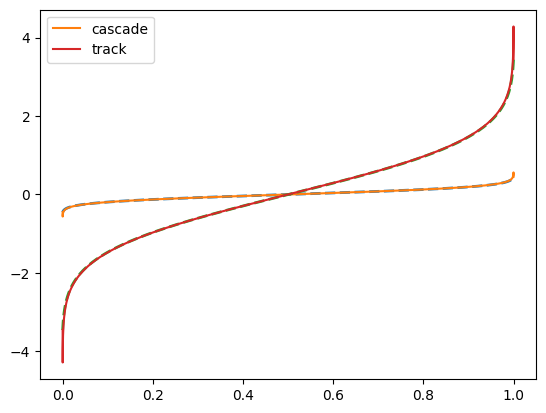

In [24]:
# Quick check :-)
plt.plot(cdf_cascade, xs_cascade, lw=2, ls="--")
plt.plot(us, cascade_inv_cdf, label="cascade")
plt.plot(cdf_track, xs_track, lw=2, ls="--")
plt.plot(us, track_inv_cdf, label="track")
plt.legend()
plt.show()

In [ ]:
with h5.File(globs["fname"], "r+") as h5f:
    if "cascade_energy_resolution" in h5f.keys():
        del h5f["cascade_energy_resolution"]
    h5f.create_group("cascade_energy_resolution")
    h5f["cascade_energy_resolution"].create_dataset("us", data=us)
    h5f["cascade_energy_resolution"].create_dataset("inv_cdf", data=cascade_inv_cdf)

    if "track_energy_resolution" in h5f.keys():
        del h5f["track_energy_resolution"]
    h5f.create_group("track_energy_resolution")
    h5f["track_energy_resolution"].create_dataset("us", data=us)
    h5f["track_energy_resolution"].create_dataset("inv_cdf", data=track_inv_cdf)

## And once again, how we sample it

In [ ]:
try:
    del cascade_inv_cdf
except NameError:
    pass
try:
    del track_inv_cdf
except NameError:
    pass
try:
    del cdf_interp_cascade
except NameError:
    pass
try:
    del cdf_interp_track
except NameError:
    pass
try:
    del cdf_cascade
except NameError:
    pass
try:
    del cdf_track
except NameError:
    pass

In [ ]:
with h5.File(globs["fname"]) as h5f:
    cascade_i = interp1d(
        h5f["cascade_energy_resolution/us"][:],
        h5f["cascade_energy_resolution/inv_cdf"][:]
    )
    track_i = interp1d(
        h5f["track_energy_resolution/us"][:],
        h5f["track_energy_resolution/inv_cdf"][:]
    )

In [ ]:
def sample_energy(interp, n=1):
    u = np.random.rand(n)
    return np.exp(interp(u))

In [ ]:
np.median(sample_energy(track_i, 100_000))

In [ ]:
h, bins = np.histogram(np.log10(sample_energy(track_i, 100_000)), bins=11)
cents = (bins[1:] + bins[:-1]) / 2
plt.step(cents, h, where="mid")

h, bins = np.histogram(np.log10(sample_energy(cascade_i, 100_000)), bins=11)
cents = (bins[1:] + bins[:-1]) / 2
plt.step(cents, h, where="mid")

plt.show()

## Finally let's do the effective area
I think this is gonna be the most "artful"

In [25]:
# Load up tabulated effective from the data release
a = np.genfromtxt("../resources/IC86_II_effectiveArea.csv")

In [26]:
dec_cents = (np.radians(np.unique(a[:,2])) + np.radians(np.unique(a[:,3]))) / 2
e_cents = (np.power(10, np.unique(a[:, 0])) + np.power(10, np.unique(a[:, 1]))) * units.GeV/ 2

In [27]:
# Plop all the effective areas into an array
effa = np.zeros((len(e_cents), len(dec_cents)))
for row in tqdm(a): 
    e = np.mean(np.power(10, row[[0, 1]])) * units.GeV
    dec = (np.radians(row[2]) + np.radians(row[3])) / 2
    idx = np.argmin(np.abs(e - e_cents))
    jdx = np.argmin(np.abs(dec - dec_cents))
    effa[idx, jdx] = row[4] * units.cm**2

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 32789.13it/s]


/var/folders/4q/ncd7kk_j2t9_syxd3gmst9mc0000gn/T/ipykernel_23667/263671106.py:5: RuntimeWarning: divide by zero encountered in log10
  np.log10(effa / units.cm**2)[::-1, :],


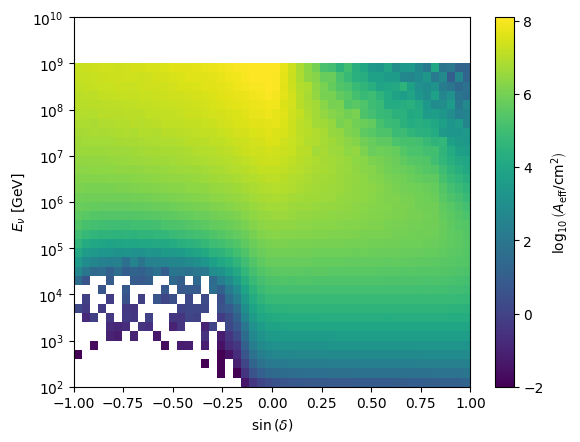

In [28]:
# Plot the data just to see what it looks like
fig, ax = plt.subplots()

im = ax.imshow(
    np.log10(effa / units.cm**2)[::-1, :],
    aspect="auto",
    extent=[
        -1, 1,
#         np.sin(a[:, [2,3]]).min(),
#         np.sin(a[:, [2,3]]).max(),
        a[:, [0, 1]].min(),
        a[:, [0, 1]].max(),
    ],
    zorder=1,
    vmin=-2,
    vmax=8.1
)

ax.set_xlabel(r"$\sin\left(\delta\right)$")
ax.set_ylabel(r"$E_{\nu}~\left[\mathrm{GeV}\right]$")

ax.set_ylim(2, 10)

ax.set_yticks(range(2,11))
ax.set_yticklabels([r"$10^{%d}$" % x for x in range(2, 11)])

cbar = plt.colorbar(im, label=r"$\log_{10}\left(A_{\mathrm{eff}} / \mathrm{cm}^{2}\right)$")

plt.show()

This spotty pocket in the bottom left corner is worrying. I've tried to come up with some clever ways to deal with it, but ultimately, I decided we are just going to ignore it for now.

/var/folders/4q/ncd7kk_j2t9_syxd3gmst9mc0000gn/T/ipykernel_23667/1349039824.py:13: RuntimeWarning: divide by zero encountered in log10
  np.log10(effa / units.cm**2)[::-1, :],


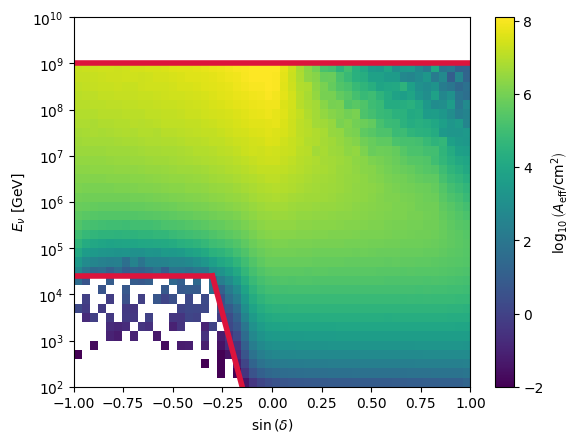

In [29]:
# Let's take a look at the proposed cuts
lower_bounds = [
    [np.log10(2.5e4 * units.GeV)],
    [-15.9862667245, np.log10(np.power(10, -0.397940008675) * units.GeV)],
]
upper_bounds = [
    [np.log10(1e9 * units.GeV)]
]

fig, ax = plt.subplots()

im = ax.imshow(
    np.log10(effa / units.cm**2)[::-1, :],
    aspect="auto",
    extent=[
        -1, 1,
#         np.sin(a[:, [2,3]]).min(),
#         np.sin(a[:, [2,3]]).max(),
        a[:, [0, 1]].min(),
        a[:, [0, 1]].max(),
    ],
    vmin=-2,
    vmax=8.1
)

plt.plot(
    [-1, -0.3],
    np.poly1d(lower_bounds[0])([-1, -0.3]) - np.log10(units.GeV),
    lw=4,
    c="crimson"
)
plt.plot(
    [-0.3, -0.15],
    np.poly1d(lower_bounds[1])([-0.3, -0.15]) - np.log10(units.GeV),
    lw=4,
    c="crimson"
)
plt.plot(
    [-1, 1],
    np.poly1d(upper_bounds[0])([-1, 1]) - np.log10(units.GeV),
    lw=4,
    c="crimson"
)

ax.set_xlabel(r"$\sin\left(\delta\right)$")
ax.set_ylabel(r"$E_{\nu}~\left[\mathrm{GeV}\right]$")

ax.set_ylim(2, 10)

ax.set_yticks(range(2,11))
ax.set_yticklabels([r"$10^{%d}$" % x for x in range(2, 11)])

cbar = plt.colorbar(im, label=r"$\log_{10}\left(A_{\mathrm{eff}} / \mathrm{cm}^{2}\right)$")

plt.show()

In [30]:
def poly_bounds(sindec, e, lower_bounds, upper_bounds):
    
    y = np.log10(e)
    
    upper_bool = False
    for bound in upper_bounds:
        f = np.poly1d(bound)
        if y < f(sindec):
            upper_bool = True
            break
    
    lower_bool = False
    for bound in lower_bounds:
        f = np.poly1d(bound)
        if y > f(sindec):
            lower_bool = True
    
    return lower_bool and upper_bool

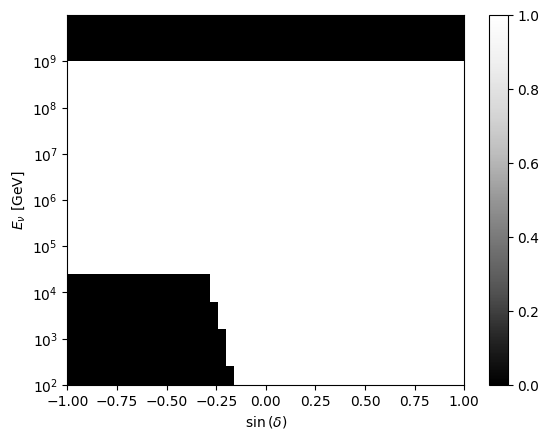

In [31]:
out = np.zeros((len(dec_cents), len(e_cents)), dtype=bool)
for idx, dec in enumerate(dec_cents):
    for jdx, e in enumerate(e_cents):
        out[idx, jdx] = poly_bounds(np.sin(dec), e, lower_bounds, upper_bounds)

out = out[:, ::-1].T
        
fig, ax = plt.subplots() 

im = ax.imshow(
    out,
    aspect="auto",
    extent=[-1, 1, a[:, [0, 1]].min(), a[:, [0, 1]].max()],
    cmap="Greys_r"
)

cbar = plt.colorbar(im)

ax.set_xlabel(r"$\sin\left(\delta\right)$")
ax.set_ylabel(r"$E_{\nu}~\left[\mathrm{GeV}\right]$")

ax.set_ylim(2, 10)

ax.set_yticks(range(2, 10))
ax.set_yticklabels([r"$10^{%d}$" % x for x in range(2, 10)])

plt.show()

/var/folders/4q/ncd7kk_j2t9_syxd3gmst9mc0000gn/T/ipykernel_23667/2255876537.py:13: RuntimeWarning: divide by zero encountered in log10
  np.where(out, np.log10(effa / units.cm**2)[::-1, :], -np.inf),


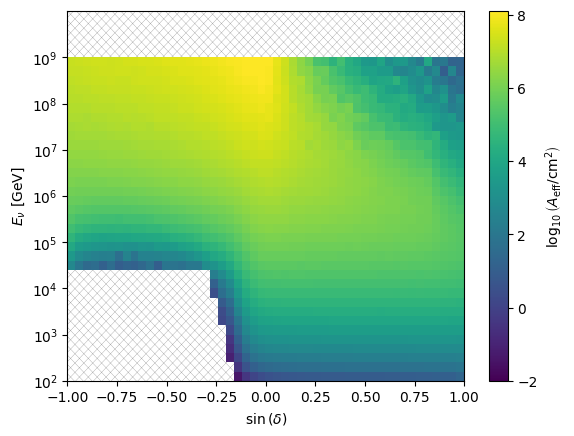

In [32]:
fig, ax = plt.subplots()

for b in np.linspace(-10, 20, 150):
    s = 4.5
    fp = lambda x: s * x + b
    fn = lambda x: -s * x + b
    xs_ = np.linspace(-1, 1, 3)
    ax.plot(xs_, fp(xs_), c="k", zorder=0, lw=0.2, alpha=0.5)
    ax.plot(xs_, fn(xs_), c="k", zorder=0, lw=0.2, alpha=0.5)
    del xs_

im = ax.imshow(
    np.where(out, np.log10(effa / units.cm**2)[::-1, :], -np.inf),
    aspect="auto",
    extent=[
        -1, 1,
        a[:, [0, 1]].min(),
        a[:, [0, 1]].max(),
    ],
    zorder=1,
    vmin=-2,
    vmax=8.1
    
)

ax.set_xlabel(r"$\sin\left(\delta\right)$")
ax.set_ylabel(r"$E_{\nu}~\left[\mathrm{GeV}\right]$")

ax.set_ylim(2, 10)

ax.set_yticks(range(2,10))
ax.set_yticklabels([r"$10^{%d}$" % x for x in range(2, 10)])

cbar = plt.colorbar(im, label=r"$\log_{10}\left(A_{\mathrm{eff}} / \mathrm{cm}^{2}\right)$")

plt.show()

In [33]:
def harmonize_bounds(bounds):
    max_length = 0
    for bound in bounds:
        l = 0
        while l<len(bound) and bound[l]==0:
            l += 1
        max_length = max(max_length, len(bound)-l)
    harmonized_bounds = np.zeros((len(bounds), max_length))
    for idx, bound in enumerate(bounds):
        bd = bound.copy()
        d = max_length - len(bd)
        if d > 0:
            bd = np.append(np.zeros(d), bd)
        harmonized_bounds[idx, :] = bd
    return harmonized_bounds

In [34]:
with h5.File(globs["fname"], "r+") as h5f:
    k = "track_effective_area"
    if k in h5f.keys():
        del h5f[k]
    h5f.create_group(k)
    h5f[k].create_dataset("declinations", data=dec_cents)
    h5f[k].create_dataset("es", data=e_cents)
    h5f[k].create_dataset("tabulated_values", data=effa)
    h5f[k].create_dataset("lower_bounds", data=harmonize_bounds(lower_bounds))
    h5f[k].create_dataset("upper_bounds", data=harmonize_bounds(upper_bounds))
    
    # For now, we're going to use the same effective area twice, but in practice this is different
    k = "cascade_effective_area"
    if k in h5f.keys():
        del h5f[k]
    h5f.create_group(k)
    h5f[k].create_dataset("declinations", data=dec_cents)
    h5f[k].create_dataset("es", data=e_cents)
    h5f[k].create_dataset("tabulated_values", data=effa)
    h5f[k].create_dataset("lower_bounds", data=harmonize_bounds(lower_bounds))
    h5f[k].create_dataset("upper_bounds", data=harmonize_bounds(upper_bounds))

## Finally let's use this

In [35]:
def effa_helper(decs, es, tabulated_values, lower_bounds, upper_bounds):
    sin_decs = np.sin(decs)
    tabulated_values_scrubbed = np.where(
        tabulated_values>0,
        tabulated_values,
        tabulated_values[tabulated_values>0].min()
    )
    i = RegularGridInterpolator((np.log(es), sin_decs), np.log(tabulated_values_scrubbed))

    def f(dec, e, interp, lbs, ubs):
        sd = np.sin(dec)
        le = np.log(e)
        # return 0 if outside of interpolator bounds
        if le < interp.grid[0][0] or le > interp.grid[0][-1]:
            return 0.0
        if sd < interp.grid[1][0] or sd > interp.grid[1][-1]:
            return 0.0
        # return 0 if bounds say so
        if not poly_bounds(sd, e, lower_bounds, upper_bounds):
            return 0.0
        return np.exp(interp((le, sd)))
    
    return lambda dec, e: f(dec, e, i, lower_bounds, upper_bounds)

In [36]:
with h5.File(globs["fname"]) as h5f:
    k = "track_effective_area"

    decs = h5f[f"{k}/declinations"]
    es = h5f[f"{k}/es"]
    tabulated_values = h5f[f"{k}/tabulated_values"]
    lower_bounds = h5f[f"{k}/lower_bounds"]
    upper_bounds = h5f[f"{k}/upper_bounds"]
    effa_f = effa_helper(decs[:], es[:], tabulated_values[:], lower_bounds[:], upper_bounds[:])

/var/folders/4q/ncd7kk_j2t9_syxd3gmst9mc0000gn/T/ipykernel_23667/3716255042.py:21: RuntimeWarning: divide by zero encountered in log10
  np.log10(effa_new / units.cm**2)[::-1, :],


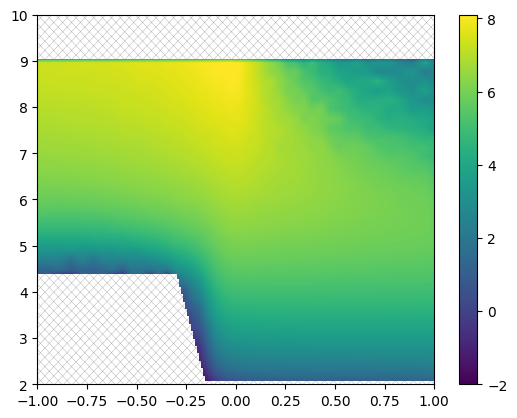

In [37]:
# Make sure this works
es_fine = np.logspace(np.log10(e_cents.min()), np.log10(e_cents.max()), 200)
decs_fine = np.linspace(-1, 1, 200)
effa_new = np.zeros(es_fine.shape + decs_fine.shape)
for idx, e in enumerate(es_fine):
    for jdx, dec in enumerate(decs_fine):
        effa_new[idx, jdx] = effa_f(dec, e)
        
fig, ax = plt.subplots()

for b in np.linspace(-10, 20, 150):
    s = 4.5
    fp = lambda x: s * x + b
    fn = lambda x: -s * x + b
    xs_ = np.linspace(-1, 1, 3)
    ax.plot(xs_, fp(xs_), c="k", zorder=0, lw=0.2, alpha=0.5)
    ax.plot(xs_, fn(xs_), c="k", zorder=0, lw=0.2, alpha=0.5)
    del xs_

im = ax.imshow(
    np.log10(effa_new / units.cm**2)[::-1, :],
    aspect="auto",
    extent=[
        -1, 1,
        a[:, [0, 1]].min(),
        a[:, [0, 1]].max(),
    ],
    zorder=1,
    vmin=-2,
    vmax=8.1
)

cbar = plt.colorbar(im)

plt.show()

# Detritis

In [ ]:
fig, ax = plt.subplots()

im = ax.imshow(
    np.log10(effa)[::-1, :],
    aspect="auto",
    extent=[
        -1, 1,
        a[:, [0, 1]].min(),
        a[:, [0, 1]].max(),
    ],
    vmin = -2,
    vmax = 8
)

ax.set_xlabel(r"$\sin\left(\delta\right)$")
ax.set_ylabel(r"$E_{\nu}~\left[\mathrm{GeV}\right]$")

ax.set_ylim(2, 9)

ax.set_yticks(range(2,10))
ax.set_yticklabels([r"$10^{%d}$" % x for x in range(2, 10)])

cbar = plt.colorbar(im)

plt.show()

#

fig, ax = plt.subplots()

im = ax.imshow(
    np.log10(new_effa)[::-1, :],
    aspect="auto",
    extent=[
        -1, 1,
        a[:, [0, 1]].min(),
        a[:, [0, 1]].max(),
    ],
    vmin = -2,
    vmax = 8
)

ax.set_xlabel(r"$\sin\left(\delta\right)$")
ax.set_ylabel(r"$E_{\nu}~\left[\mathrm{GeV}\right]$")

ax.set_ylim(2, 9)

ax.set_yticks(range(2,10))
ax.set_yticklabels([r"$10^{%d}$" % x for x in range(2, 10)])

cbar = plt.colorbar(im)

plt.show()

In [ ]:
for idx in range(50):
    mask = slice(idx * 40, (idx+1) * 40)
    es = np.mean(np.power(10, a[mask, [0, 1]]), axis=1)
    plt.step(es, effa[:, idx], where="mid")
    plt.loglog()
    plt.show()

In [ ]:
for idx in range(50):
    mask = slice(idx * 40, (idx+1) * 40)
    es = np.mean(np.power(10, a[mask, [0, 1]]), axis=1)
    plt.step(es, new_effa[:, idx], where="mid")
    plt.loglog()
    plt.show()

In [29]:
h5f = h5.File("/Users/jlazar/Downloads/Signalness.h5")

In [45]:
for k in h5f["Detector/IC"].keys():
    print(k, h5f[f"Detector/IC/{k}"][...].shape)

energies (6,)
signalness (6, 5)
zens (6, 5)


In [43]:
np.cos(h5f["Detector/IC/signalness"][:]).shape

(6, 5)